<a href="https://colab.research.google.com/github/brendharosa/primeiro1/blob/main/Projeto_Pr%C3%A1tico_Individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise do Perfil dos Candidatos do Rio Grande do Sul nas Eleições Municipais de 2024**
Este trabalho tem como objetivo realizar uma análise dos dados dos candidatos do Rio Grande do Sul nas eleições municipais de 2024.

A análise será desenvolvida utilizando a linguagem Python e bibliotecas voltadas para manipulação e análise de dados. Serão analisadas informações como idade, sexo, escolaridade, cargo disputado, partido e município dos candidatos.

O objetivo é identificar as principais características do perfil dos candidatos e transformar os dados disponíveis em informações mais fáceis de compreender.


**Fonte dos dados:** os dados utilizados foram obtidos no Portal de Dados Abertos do Tribunal Superior Eleitoral (TSE), no conjunto "Candidatos - 2024", utilizando arquivo referente ao Rio Grande do Sul.

**Questão investigada:** quais são as principais características do perfil dos candidatos do Rio Grande do Sul nas eleições municipais de 2024, considerando gênero, idade, escolaridade, cargo, partido e município?

In [79]:
# Importa a biblioteca Pandas para trabalhar com os dados
import pandas as pd

In [120]:
# Lê o arquivo CSV com os dados dos candidatos do Rio Grande do Sul
dados = pd.read_csv("consulta_cand_2024_RS.csv", sep=";", encoding="latin1")

# Mostra as cinco primeiras linhas do conjunto de dados
dados.head()

,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,...,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO
0,07/10/2026,02:16:02,2024,1,ELEIÇÃO SUPLEMENTAR,1,6268,Eleição Suplementar Cachoeirinha - RS,12/04/2026,MUNICIPAL,...,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),1,BRANCA,278,VEREADOR,4,NÃO ELEITO
1,07/10/2026,02:16:02,2024,1,ELEIÇÃO SUPLEMENTAR,1,6268,Eleição Suplementar Cachoeirinha - RS,12/04/2026,MUNICIPAL,...,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),1,BRANCA,931,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",4,NÃO ELEITO
2,07/10/2026,02:16:02,2024,1,ELEIÇÃO SUPLEMENTAR,1,6268,Eleição Suplementar Cachoeirinha - RS,12/04/2026,MUNICIPAL,...,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,190,FOTÓGRAFO E ASSEMELHADOS,4,NÃO ELEITO
3,07/10/2026,02:16:02,2024,2,ELEIÇÃO ORDINÁRIA,1,619,Eleições Municipais 2024,06/10/2024,MUNICIPAL,...,6,ENSINO MÉDIO COMPLETO,3,CASADO(A),1,BRANCA,999,OUTROS,4,NÃO ELEITO
4,07/10/2026,02:16:02,2024,2,ELEIÇÃO ORDINÁRIA,1,619,Eleições Municipais 2024,06/10/2024,MUNICIPAL,...,6,ENSINO MÉDIO COMPLETO,1,SOLTEIRO(A),1,BRANCA,254,VIGILANTE,4,NÃO ELEITO


In [126]:
# Mostra a quantidade de linhas e colunas do conjunto de dados
dados.shape

(29040, 50)

In [86]:
# Mostra o nome de cada coluna em uma linha
for coluna in dados.columns:
  print(coluna)

DT_GERACAO
HH_GERACAO
ANO_ELEICAO
CD_TIPO_ELEICAO
NM_TIPO_ELEICAO
NR_TURNO
CD_ELEICAO
DS_ELEICAO
DT_ELEICAO
TP_ABRANGENCIA
SG_UF
SG_UE
NM_UE
CD_CARGO
DS_CARGO
SQ_CANDIDATO
NR_CANDIDATO
NM_CANDIDATO
NM_URNA_CANDIDATO
NM_SOCIAL_CANDIDATO
NR_CPF_CANDIDATO
DS_EMAIL
CD_SITUACAO_CANDIDATURA
DS_SITUACAO_CANDIDATURA
TP_AGREMIACAO
NR_PARTIDO
SG_PARTIDO
NM_PARTIDO
NR_FEDERACAO
NM_FEDERACAO
SG_FEDERACAO
DS_COMPOSICAO_FEDERACAO
SQ_COLIGACAO
NM_COLIGACAO
DS_COMPOSICAO_COLIGACAO
SG_UF_NASCIMENTO
DT_NASCIMENTO
NR_TITULO_ELEITORAL_CANDIDATO
CD_GENERO
DS_GENERO
CD_GRAU_INSTRUCAO
DS_GRAU_INSTRUCAO
CD_ESTADO_CIVIL
DS_ESTADO_CIVIL
CD_COR_RACA
DS_COR_RACA
CD_OCUPACAO
DS_OCUPACAO
CD_SIT_TOT_TURNO
DS_SIT_TOT_TURNO


In [88]:
# Mostra o tipo de dado de cada coluna
dados.dtypes

,0
DT_GERACAO,object
HH_GERACAO,object
ANO_ELEICAO,int64
CD_TIPO_ELEICAO,int64
NM_TIPO_ELEICAO,object
NR_TURNO,int64
CD_ELEICAO,int64
DS_ELEICAO,object
DT_ELEICAO,object
TP_ABRANGENCIA,object


In [89]:
# Verifica a quantidade de valores ausentes em cada coluna
dados.isnull().sum()

,0
DT_GERACAO,0
HH_GERACAO,0
ANO_ELEICAO,0
CD_TIPO_ELEICAO,0
NM_TIPO_ELEICAO,0
NR_TURNO,0
CD_ELEICAO,0
DS_ELEICAO,0
DT_ELEICAO,0
TP_ABRANGENCIA,0


In [90]:
# Guarda a quantidade de valores ausentes de cada coluna
ausentes = dados.isnull().sum()

# Mostra apenas as colunas que possuem valores ausentes
ausentes[ausentes > 0]

,0


In [91]:
# Verifica a quantidade de registros duplicados no conjunto de dados
dados.duplicated().sum()

np.int64(0)

**Possível problema identificado:** durante a exploração do conjunto de dados, foi observado que existem registros de eleições suplementares, além da eleição municipal ordinária de 2024. Como o objetivo do trabalho é analisar o perfil dos candidatos das eleições municipais de 2024, esses registros precisam ser tratados antes das análises.

In [92]:
# Mantém apenas os registros da eleição ordinária de 2024
dados = dados[
    (dados["ANO_ELEICAO"] == 2024) &
    (dados["NM_TIPO_ELEICAO"] == "ELEICAO ORDINÁRIA")
]

# Mostra a quantidade de registros após o filtro
dados.shape

(0, 50)

**Preparação dos dados:** Na preparação dos dados, foram verificados valores ausentes e registros duplicados. Como não foram encontrados valores nessas condições, não foi necessário realizar exclusões por esses motivos. Também foram mantidos apenas os registros da eleição ordinária de 2024, removendo 22 registros referentes a eleições suplementares. Assim, o conjunto final utilizado na análise ficou com 29.040 registros.

In [93]:
# Mostra os tipos de eleição existentes no conjunto de dados
dados["NM_TIPO_ELEICAO"].unique()

array([], dtype=object)

In [94]:
# Lê novamente o arquivo original
dados = pd.read_csv(
    "consulta_cand_2024_RS.csv",
    sep=";",
    encoding="latin1"
)

In [95]:
# Mostra os anos existentes no conjunto de dados
dados["ANO_ELEICAO"].unique()

array([2024])

In [125]:
# Remove possíveis espaços antes ou depois do tipo de eleição
dados["NM_TIPO_ELEICAO"] = dados["NM_TIPO_ELEICAO"].str.strip()

# Mantém apenas os registros da eleição ordinária
dados = dados[dados["NM_TIPO_ELEICAO"] == "ELEIÇÃO ORDINÁRIA"]

# Mostra a quantidade de registros após o filtro
dados.shape

(29040, 50)

In [76]:
# Conta quantos candidatos existem de cada gênero
dados["DS_GENERO"].value_counts()

,count
DS_GENERO,
MASCULINO,18966
FEMININO,10074


In [97]:
# Calcula o percentual de candidatos de cada gênero
percentual_genero = dados["DS_GENERO"].value_counts(normalize=True) * 100

percentual_genero.apply(lambda x: f"{x:.2f}%")

,proportion
DS_GENERO,
MASCULINO,65.31%
FEMININO,34.69%


In [98]:
# Converte a coluna de data de nascimento para o formato de data
dados["DT_NASCIMENTO"] = pd.to_datetime(
    dados["DT_NASCIMENTO"],
    format="%d/%m/%Y"
)

# Mostra as primeiras datas de nascimento após a conversão
dados["DT_NASCIMENTO"].head()

,DT_NASCIMENTO
3,1960-10-29
4,1986-06-30
5,1985-03-02
6,1963-03-10
7,1989-03-01


In [99]:
# Converte a coluna da data da eleição para o formato de data
dados["DT_ELEICAO"] = pd.to_datetime(
    dados["DT_ELEICAO"],
    format="%d/%m/%Y"
)

# Calcula a idade aproximada dos candidatos na data da eleição
dados["IDADE"] = (
    (dados["DT_ELEICAO"] - dados["DT_NASCIMENTO"]).dt.days // 365
)

#Mostra as primeiras idades calculadas
dados["IDADE"].head()

,IDADE
3,63
4,38
5,39
6,61
7,35


In [100]:
# Calcula a idade média dos candidatos
media_idade = dados["IDADE"].mean()

# Mostra a menor idade
menor_idade = dados["IDADE"].min()

# Mostra a maior idade
maior_idade = dados["IDADE"].max()

# Mostra a idade média aproximada
print("Idade média dos candidatos:", round(media_idade), "anos")
print("Menor idade dos candidatos:", round(menor_idade), "anos")
print("Maior idade dos candidatos:", round(maior_idade), "anos")

Idade média dos candidatos: 49 anos
Menor idade dos candidatos: 17 anos
Maior idade dos candidatos: 90 anos


In [101]:
# Cria faixas etárias para classificar os candidatos por idade
def faixa_etaria(idade):
  if idade < 30:
    return "Até 29 anos"
  elif idade < 40:
    return "30 a 39 anos"
  elif idade < 50:
    return "40 a 49 anos"
  elif idade < 60:
    return "50 a 59 anos"
  else:
      return "60 anos ou mais"

# Cria uma nova coluna com a faixa etária de cada candidato
dados["FAIXA_ETARIA"] = dados["IDADE"].apply(faixa_etaria)

# Conta quantos candidatos existem em cada faixa etária
dados["FAIXA_ETARIA"].value_counts()

,count
FAIXA_ETARIA,
40 a 49 anos,8320
50 a 59 anos,8208
60 anos ou mais,5718
30 a 39 anos,5065
Até 29 anos,1729


In [102]:
# Conta quantos candidatos existem em cada nível de escolaridade
dados["DS_GRAU_INSTRUCAO"].value_counts()

,count
DS_GRAU_INSTRUCAO,
ENSINO MÉDIO COMPLETO,10072
SUPERIOR COMPLETO,8238
ENSINO FUNDAMENTAL INCOMPLETO,3922
ENSINO FUNDAMENTAL COMPLETO,3064
SUPERIOR INCOMPLETO,2045
ENSINO MÉDIO INCOMPLETO,1333
LÊ E ESCREVE,366


In [103]:
# Conta quantos candidatos existem em cada cargo
dados["DS_CARGO"].value_counts()

,count
DS_CARGO,
VEREADOR,26576
VICE-PREFEITO,1240
PREFEITO,1224


In [104]:
# Conta quantos candidatos existem em cada partido
partidos = dados["SG_PARTIDO"].value_counts()

# Mostra os 10 partidos com mais candidatos
partidos.head(10)

,count
SG_PARTIDO,
PP,4628
MDB,4383
PDT,3229
PL,2897
PT,2723
PSDB,1944
REPUBLICANOS,1803
UNIÃO,1792
PSB,1283


In [105]:
# Conta quantos candidatos existem em cada município
municipios = dados["NM_UE"].value_counts()

#Mostra os 10 municípios com mais candidatos
municipios.head(10)

,count
NM_UE,
PORTO ALEGRE,538
CANOAS,358
CAXIAS DO SUL,357
GRAVATAÍ,340
VIAMÃO,307
ALVORADA,293
GUAÍBA,293
RIO GRANDE,291
SANTA MARIA,280


In [106]:
# Compara a quantidade de candidatos por cargo e gênero
cargo_genero = pd.crosstab(
    dados["DS_CARGO"],
    dados["DS_GENERO"]
)

# Mostra a tabela com a comparação
cargo_genero

DS_GENERO,FEMININO,MASCULINO
DS_CARGO,,
PREFEITO,130,1094
VEREADOR,9678,16898
VICE-PREFEITO,266,974


In [107]:
# Compara a escolaridade dos candidatos de acordo com o cargo disputado
escolaridade_cargo = pd.crosstab(
    dados["DS_CARGO"],
    dados["DS_GRAU_INSTRUCAO"]
)

# Mostra a tabela com a comparação
escolaridade_cargo

DS_GRAU_INSTRUCAO,ENSINO FUNDAMENTAL COMPLETO,ENSINO FUNDAMENTAL INCOMPLETO,ENSINO MÉDIO COMPLETO,ENSINO MÉDIO INCOMPLETO,LÊ E ESCREVE,SUPERIOR COMPLETO,SUPERIOR INCOMPLETO
DS_CARGO,,,,,,,
PREFEITO,39,80,300,17,1,702,85
VEREADOR,2949,3715,9417,1284,359,6965,1887
VICE-PREFEITO,76,127,355,32,6,571,73


<Axes: xlabel='DS_GENERO'>

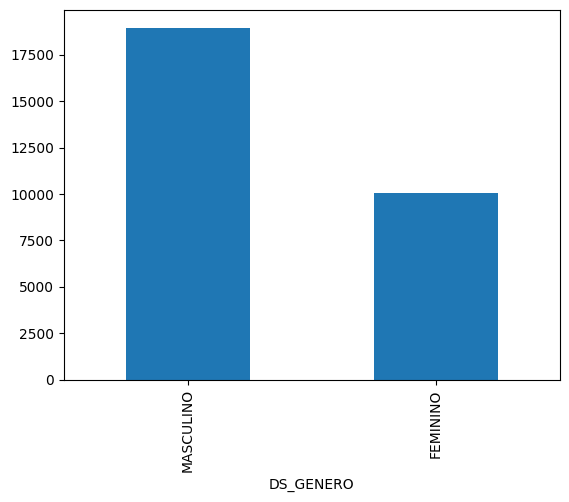

In [108]:
# Cria um gráfico com a quantidade de candidatos por gênero
dados["DS_GENERO"].value_counts().plot(kind="bar")


O gráfico acima apresenta a quantidade de candidatos por gênero.
Masculino: 18.966
Feminino: 10.074


# **CONCLUSÃO**
A análise dos dados dos candidatos do Rio Grande do Sul nas eleições municipais de 2024 permitiu identificar algumas características principais do perfil das candidaturas.

Ao todo, foram analisados 29.062 registros. A maioria dos candidatos é do gênero masculino, representando cerca de 65,31% do total, enquanto o gênero feminino representa 34,69%.

A idade média dos candidatos ficou em aproximadamente 49 anos. A faixa etária com maior quantidade de candidatos foi de 40 a 49 anos, seguida pela faixa de 50 a 59 anos.

Também foi possível perceber que a maior parte das candidaturas foi para o cargo de vereador, com 26.578 registros. Além disso, a análise permitiu identificar os partidos e municípios com maior número de candidatos.

Durante o desenvolvimento do trabalho, foram utilizados recursos da biblioteca Pandas para organizar, consultar e analisar os dados, além de funções e estruturas condicionais em Python.

De forma geral, o trabalho ajudou a colocar em prática os conteúdos estudados na disciplina e mostrou como os dados podem ser utilizados para obter informações de forma mais organizada e fácil de entender.